In [1]:
import pandas as pd

# df = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\raw_analyst_ratings.csv')

# Assign the loaded DataFrame 'df' to 'df_news' for consistent analysis
df_news = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\raw_analyst_ratings.csv')

if 'df_news' in locals() and not df_news.empty:
    print("\n--- Performing Descriptive Statistics ---")

    # a) Obtain basic statistics for textual lengths (e.g., headline character count distribution)
    if 'headline' in df_news.columns:
        df_news['headline_length'] = df_news['headline'].apply(len)
        print("\n1. Headline Character Count Distribution:")
        print(df_news['headline_length'].describe())
    else:
        print("\nWarning: 'headline' column not found for textual length analysis.")

    # b) Count articles per publisher to identify which sources are most active
    if 'publisher' in df_news.columns:
        print("\n2. Articles per Publisher:")
        print(df_news['publisher'].value_counts())
    else:
        print("\nWarning: 'publisher' column not found for articles per publisher analysis.")

    # c) Analyze publication dates to identify trends over time
    if 'date' in df_news.columns:
        print("\n3. Publication Dates Trends (Articles per Day):")
        try:
            # Use errors='coerce' to turn unparseable dates into NaT and ensure datetime dtype
            # Also add utc=True as suggested by the FutureWarning for mixed time zones
            df_news['date'] = pd.to_datetime(df_news['date'], format='mixed', dayfirst=False, errors='coerce', utc=True)
            # Drop NaT values before counting dates to avoid errors if any unparseable dates exist
            print(df_news['date'].dropna().dt.date.value_counts().sort_index())
        except Exception as e:
            print(f"Could not convert 'date' to datetime. Error: {e}")
    else:
        print("\nWarning: 'date' column not found for date trend analysis.")
else:
    print("\nError: df_news is empty or not properly loaded. Please ensure your FNSPID data is in 'df_news'.")


--- Performing Descriptive Statistics ---

1. Headline Character Count Distribution:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

2. Articles per Publisher:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64

3. Publication Dates Trends (Articles per Day):
date
2009-02-14      1
2009-04-27      2
2009-04-29      1
2009-05-22      1
2009-05-27      6
             ... 
2020-06-07     25
2020-06-08    765
2020-06-09    803
2020-06-10    807
2020-06-11    544
Name: count, Length: 3955, dtype: int64


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

if 'headline' in df_news.columns:
    print("\n--- TF-IDF Analysis (Top 20 Keywords) ---")
    
    # For faster processing, especially with large datasets, work on a sample
    # You can adjust the sample_size as needed.
    sample_size = 100000 # Using 100,000 headlines for quicker analysis
    if len(df_news) > sample_size:
        sampled_headlines = df_news['headline'].sample(n=sample_size, random_state=42).tolist()
        print(f"Analyzing a sample of {sample_size} headlines.")
    else:
        sampled_headlines = df_news['headline'].tolist()
        print(f"Analyzing all {len(sampled_headlines)} headlines.")

    # Initialize TfidfVectorizer
    tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
    tfidf_matrix = tfidf_vectorizer.fit_transform(sampled_headlines)

    # Get feature names (words)
    tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

    # Sum TF-IDF scores for each word across all headlines
    tfidf_sums = tfidf_matrix.sum(axis=0)

    # Convert to 1D numpy array ensuring correct shape
    tfidf_sums_array = np.asarray(tfidf_sums).flatten()

    # Get indices of words with highest TF-IDF scores
    most_important_words_indices = tfidf_sums_array.argsort()[::-1]

    # Print top 20 keywords by TF-IDF score
    if tfidf_sums_array.size > 0:
        for i in most_important_words_indices[:20]:
            print(f"{tfidf_feature_names[i]}: {tfidf_sums_array[i]:.2f}")
    else:
        print("No important keywords found with TF-IDF (tfidf_sums is empty).")
else:
    print("Warning: 'headline' column not found for TF-IDF analysis.")


--- TF-IDF Analysis (Top 20 Keywords) ---
Analyzing a sample of 100000 headlines.
stocks: 3064.65
market: 2321.49
vs: 2245.87
benzinga: 2094.33
est: 2060.20
earnings: 1954.36
reports: 1843.58
eps: 1832.35
shares: 1805.28
update: 1732.49
downgrades: 1699.61
week: 1612.54
upgrades: 1609.52
buy: 1466.25
announces: 1463.31
pt: 1443.68
52: 1372.46
sales: 1296.68
mid: 1267.35
price: 1220.02


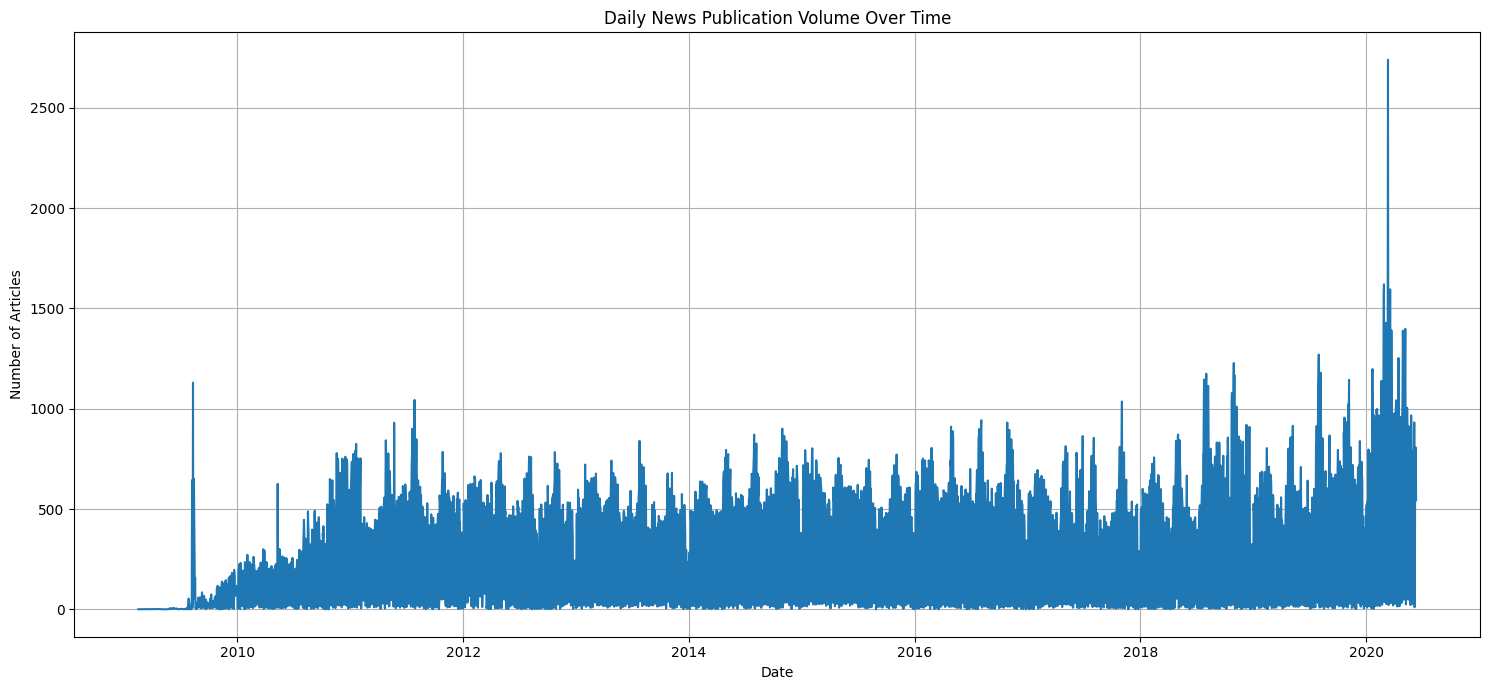

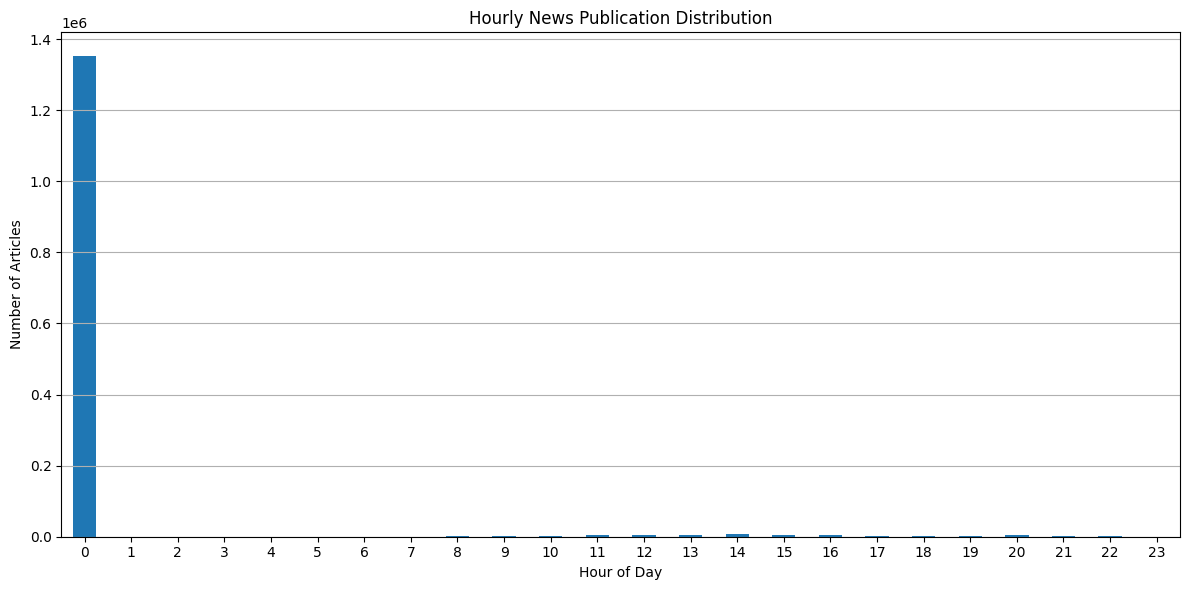

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date' column is in datetime format
if 'date' in df_news.columns:
    # Using errors='coerce' to handle any unparseable dates by turning them into NaT
    df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True)
    # Drop rows where 'date' could not be parsed
    df_news.dropna(subset=['date'], inplace=True)

    # Extract publication day and hour
    df_news['publication_day'] = df_news['date'].dt.date
    df_news['publication_hour'] = df_news['date'].dt.hour

    # 1. Daily News Volume
    daily_news_volume = df_news['publication_day'].value_counts().sort_index()

    plt.figure(figsize=(15, 7))
    daily_news_volume.plot(kind='line')
    plt.title('Daily News Publication Volume Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Articles')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2. Hourly News Volume
    hourly_news_volume = df_news['publication_hour'].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    hourly_news_volume.plot(kind='bar')
    plt.title('Hourly News Publication Distribution')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: 'date' column not found for time series analysis.")

In [6]:
import re

if 'publisher' in df_news.columns:
    print("\n--- Publisher Activity Analysis ---")

    # 1. Identify the most active publishers
    print("Top 20 Most Active Publishers:")
    print(df_news['publisher'].value_counts().head(20))

    # 2. Extract unique domains if publisher names are email addresses
    email_pattern = r"^[a-zA-Z0-9._%+-]+@([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})$"
    email_publishers = df_news['publisher'][df_news['publisher'].apply(lambda x: bool(re.match(email_pattern, str(x))))]

    if not email_publishers.empty:
        print("\n--- Organizational Contribution Patterns (from Email Domains) ---")
        email_domains = email_publishers.apply(lambda x: re.match(email_pattern, str(x)).group(1))
        print("Top 10 Email Domains:")
        print(email_domains.value_counts().head(10))
    else:
        print("\nNo email-like publisher names found for domain extraction.")

    # 3. Further characterization of coverage would require more in-depth NLP
    # For instance, analyzing topics/keywords per publisher.
    print("\n*Further analysis could involve characterizing the coverage of top publishers by analyzing their headlines using NLP techniques (e.g., topic modeling or keyword extraction specific to each publisher).*")
else:
    print("Warning: 'publisher' column not found for publisher analysis.")


--- Publisher Activity Analysis ---
Top 20 Most Active Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

--- Organizational Contribution Patterns (from Email Domains) ---
Top 10 Email Domains:
publisher
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net     